Day11 Morphological operations

Until now we had been learning about pixel intensity based operations now we will be working on the shape.


There are multiple forms forms of operations based on what we want

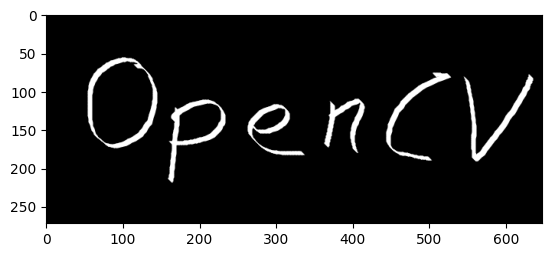

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("opencv_inv.png",0)

plt.imshow(img,vmax=255,vmin=0,cmap='gray')
plt.show()

1 Erosion

Structural element=[[1 1 1],[1 1 1],[1 1 1]]
this is used to identify interested region

every elemnt under the structural elemnt should be white for the central elemnt to be white. this erodes boudries

Use case:
remove isolated white pixels
Separate touching objects
shrink objects
remove thin protrusions

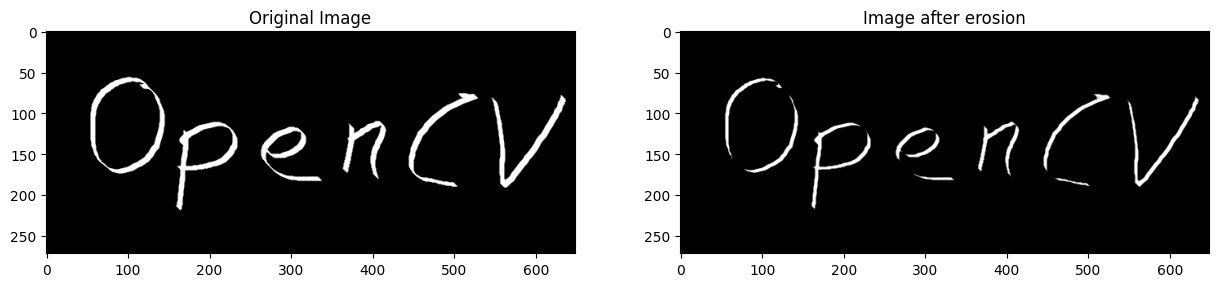

In [31]:


SE=np.ones((3,3),np.uint8)

erosion=cv2.erode(img,SE,iterations=1)
#cv2.erode for binary will give black or white
#cv2.erode for grey will give minimum value in the structural elemnt(SE)
#cv2.erode for color will give minimum value in the structural elemnt(SE) for each channel independently


plt.figure(figsize=(15,15))
#plt.suptitle("Second Order Derivative Laplacian",fontsize=16)

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(erosion,cmap="gray",vmin=0,vmax=255)
plt.title("Image after erosion")

plt.show()


2 Dilation
SE = =[[1 1 1],[1 1 1],[1 1 1]]

at least 1 element under the structural element should be white for the central elemnt to be white. this expands the image

Use case:
- Combine nearby objects
- Magnify objects
- Fill holes

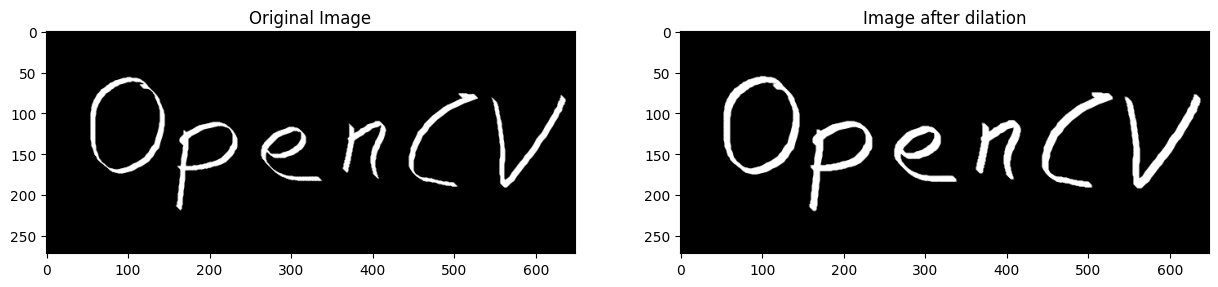

In [32]:
SE=np.ones((3,3),np.uint8)

dilate=cv2.dilate(img,SE,iterations=1)
#cv2.erode for binary will give black or white
#cv2.erode for grey will give minimum value in the structural elemnt(SE)
#cv2.erode for color will give minimum value in the structural elemnt(SE) for each channel independently


plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(dilate,cmap="gray",vmin=0,vmax=255)
plt.title("Image after dilation")

plt.show()

Combine erosion and dilation you get opening and closing

- Opening: erosion followed by dilation
    - Used for cleaning white noise
- Clossing: dilation followed by erosion
    - USed to fill black holes

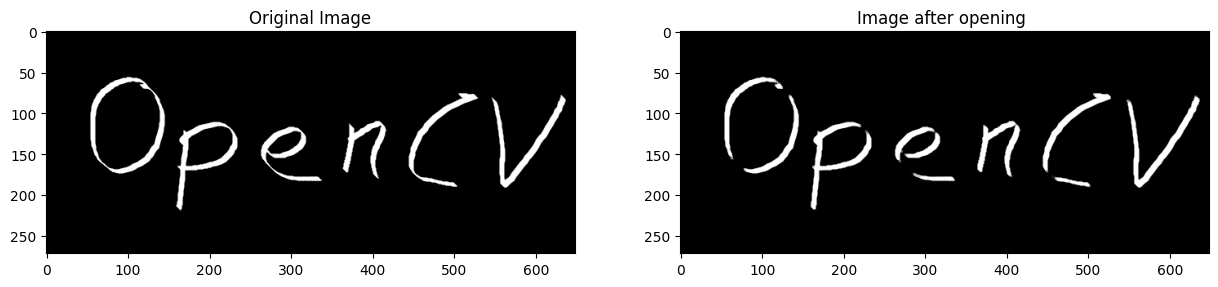

In [33]:
opening=cv2.morphologyEx(img,cv2.MORPH_OPEN,SE)

plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(opening,cmap="gray",vmin=0,vmax=255)
plt.title("Image after opening ")
plt.show()
 

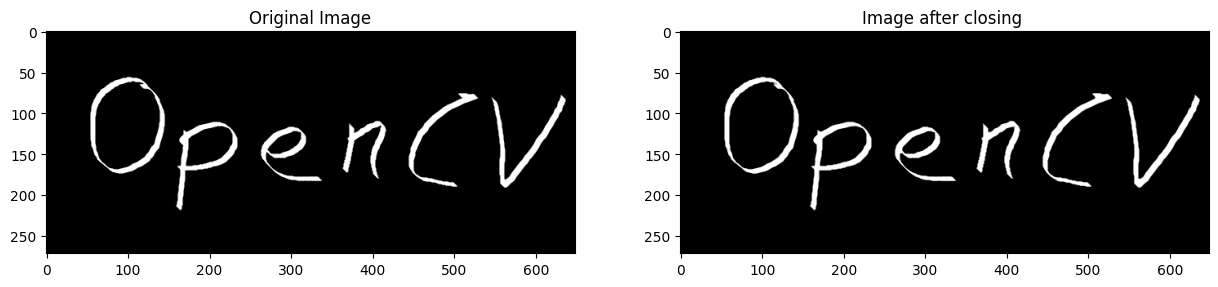

In [34]:
closing=cv2.morphologyEx(img,cv2.MORPH_CLOSE,SE)

plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(closing,cmap="gray",vmin=0,vmax=255)
plt.title("Image after closing ")
plt.show()

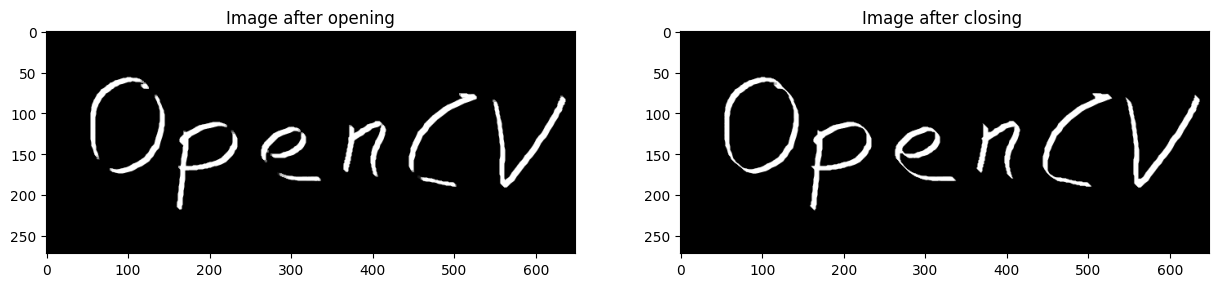

In [35]:
plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(opening,cmap="gray",vmin=0,vmax=255)
plt.title("Image after opening")

plt.subplot(1,2,2)
plt.imshow(closing,cmap="gray",vmin=0,vmax=255)
plt.title("Image after closing ")
plt.show()

Mophological gradient: Used to highlight boundry of the object based on their shape
Gradient =dilation - erosion



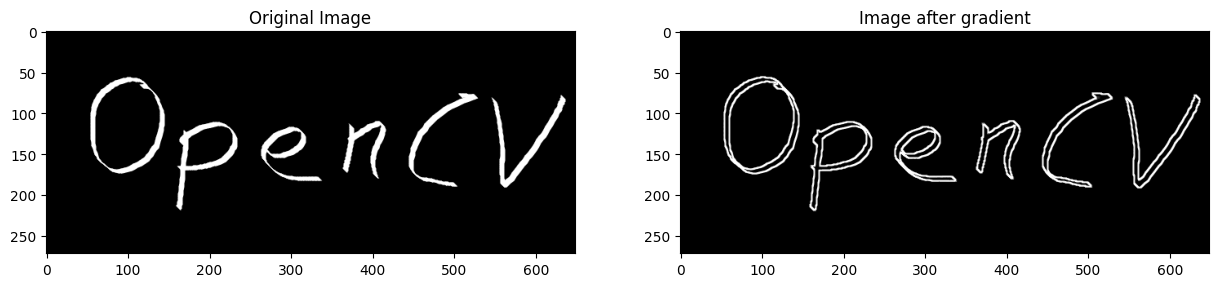

In [36]:
gradient=cv2.morphologyEx(img,cv2.MORPH_GRADIENT,SE)
plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(gradient,cmap="gray",vmin=0,vmax=255)
plt.title("Image after gradient")
plt.show()

Top hat Tranform: Original-Opening

Extracts small bright objects that were removed while Opening

Use cases:
- Bright Stars in Astronomical images
- Small vehicles in satellite imagery 
- Tiny bright defects in industrial inspection

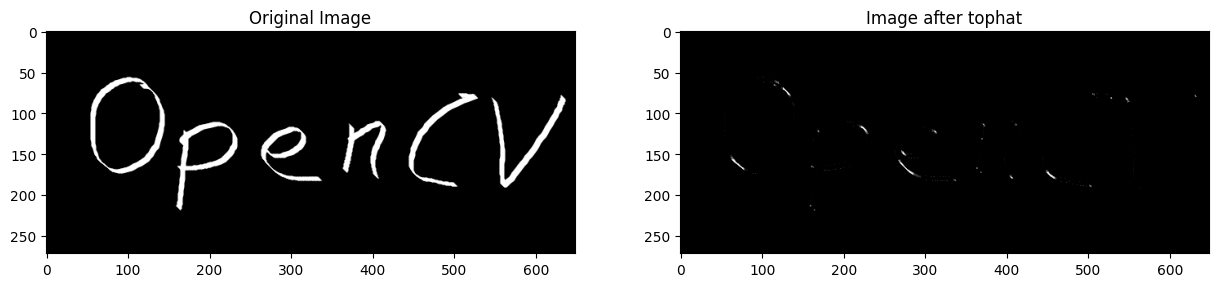

In [37]:
tophat=cv2.morphologyEx(img,cv2.MORPH_TOPHAT,SE)
plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(tophat,cmap="gray",vmin=0,vmax=255)
plt.title("Image after tophat")
plt.show()

Black hat Tranform: Closing-Original

Extracts small dark objects that were removed while Closing

Use cases:
- Detecting cracks
- Dark scratches  
- small shadows

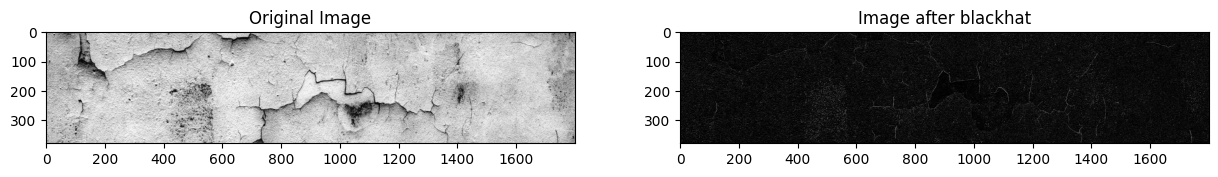

In [38]:
crack=cv2.imread("crackDetection.jpg",0)

blackhat=cv2.morphologyEx(crack,cv2.MORPH_BLACKHAT,SE)
plt.figure(figsize=(15,15))

plt.subplot(1,2,1)
plt.imshow(crack,cmap="gray",vmin=0,vmax=255)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(blackhat,cmap="gray",vmin=0,vmax=255)
plt.title("Image after blackhat")
plt.show()

Different types of kernels 
- rectangle
- elipse
- cross

In [39]:
rect=cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
ellipse=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
cross=cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))

print(rect)
print(ellipse)
print(cross)


[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]
